<h2 style="color:blue" align="center">Insurance Price Prediction</h2>

#### Import the necessary libraries

In [1]:
import random as python_random
import time, math 
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler 

import tensorflow as tf
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Dense 
from keras.callbacks import Callback, CSVLogger  

import warnings
warnings.filterwarnings('ignore')

#### Reserve GPU memory for the execution

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


#### Load the dataset

In [3]:
df = pd.read_csv('../Dataset/insurance.csv') 

In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Data pre-processing

In [6]:
# one-hot encode the dataframe
df1 = df[['sex','smoker','region']]
df1 = pd.get_dummies(df1)
df1.head()

,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,1,0,0,1,0,0,0,1
1,0,1,1,0,0,0,1,0
2,0,1,1,0,0,0,1,0
3,0,1,1,0,0,1,0,0
4,0,1,1,0,0,1,0,0


In [7]:
# Normalization
df2 = df[['age','bmi','children']]
mms = MinMaxScaler()
mms.fit(df2)
df2_normalized = mms.transform(df2) 
df2 = pd.DataFrame(df2_normalized,columns=['age','bmi','children'])
df2.head()

,age,bmi,children
0,0.021739,0.321227,0.0
1,0.000000,0.479150,0.2
2,0.217391,0.458434,0.6
3,0.326087,0.181464,0.0
4,0.304348,0.347592,0.0


In [8]:
X = pd.concat([df2,df1],axis=1)
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0.321227,0.0,1,0,0,1,0,0,0,1
1,0.000000,0.479150,0.2,0,1,1,0,0,0,1,0
2,0.217391,0.458434,0.6,0,1,1,0,0,0,1,0
3,0.326087,0.181464,0.0,0,1,1,0,0,1,0,0
4,0.304348,0.347592,0.0,0,1,1,0,0,1,0,0


In [9]:
Y = df[["charges"]]
scaler_MinMax2 = MinMaxScaler()
Y = scaler_MinMax2.fit_transform(pd.DataFrame(Y)) 
Y[:5]

array([[0.25161076],
       [0.00963595],
       [0.05311516],
       [0.33301003],
       [0.04381556]])

#### Split the dataset into training and testing set

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2) 

In [11]:
X_train.shape

(1070, 11)

In [12]:
X_train[:5]

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
962,0.978261,0.517622,0.2,1,0,1,0,0,0,1,0
984,0.043478,0.380818,1.0,0,1,1,0,1,0,0,0
299,0.652174,0.347592,0.2,1,0,1,0,0,1,0,0
836,0.391304,0.418079,0.0,0,1,1,0,0,0,0,1
311,0.021739,0.235136,0.0,1,0,1,0,0,0,0,1


#### Define DNN model

In [13]:
python_random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)
opti_name = ''

def get_model(): 
    tf.keras.backend.clear_session()
    model = Sequential([ 
        Dense(1, input_dim = 11, activation='linear') 
    ], name = "DNN_model")
    
    global opti_name 
    
   # General SGD
    opti = keras.optimizers.SGD(learning_rate=0.001)
    opti_name = 'SGD'
    
    # Momentum
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.6)
    #opti_name = 'Momentum'
    
    # Nesterov Accelerated Gradient 
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.4, nesterov=True)
    #opti_name = 'NAG'
    
    # Adagrad
    #opti = keras.optimizers.Adagrad(learning_rate=0.001) 
    #opti_name = 'AdaGrad' 
    
    # RMSprop 
    #opti = keras.optimizers.RMSprop(learning_rate=0.001)
    #opti_name = 'RMSprop'
    
    # Adadelta
    #opti = keras.optimizers.Adadelta(learning_rate=0.001) 
    #opti_name = 'AdaDelta' 
    
    # Adam
    #opti = keras.optimizers.Adam(learning_rate=0.001) 
    #opti_name = 'Adam'     
    
    # Adamax
    #opti = keras.optimizers.Adamax(learning_rate=0.001) 
    #opti_name = 'AdaMax'
    
    # Nadam
    #opti = keras.optimizers.Nadam(learning_rate=0.001) 
    #opti_name = 'Nadam'  
    
    model.compile(
        optimizer = opti,
        loss = 'mse'  
    )
    
    return model

#### Custom callbacks

HMS

In [14]:
class CustomCallbackHMS(Callback):  
    initial_weights = 0
    previous_weights = 0
    call_hm = 0 
    temp_model = 0
    r = 1
    t = 100
    
    def __init__(self, mod):
        self.temp_model = mod
        
    def on_train_begin(self, logs=None):
        self.initial_weights = self.temp_model.get_weights() 
        self.initial_weights = np.array(self.initial_weights,dtype=object)
        self.previous_weights = self.initial_weights
        # Harmonic mean based weights calculation
        self.call_hm = np.vectorize(self.apply_hm)  
             
    def on_epoch_end(self, epoch, logs={}):    
        # Minimizing HMS factor every 100 epoch
        if (epoch+1)%self.t == 0:
            self.r = round(self.r *0.9,4)  
        
        num_layers = len(self.temp_model.layers)  
        current_weights = self.temp_model.get_weights()
        current_weights = np.array(current_weights,dtype=object)        

        for i in range(num_layers):  
            # Harmonic mean based weights calculation
            tensor1 = tf.convert_to_tensor(self.previous_weights[i])
            tensor2 = tf.convert_to_tensor(current_weights[i])
            current_weights[i] = self.call_hm(tensor1, tensor2, self.r)   
            
        # Updating the model with new weights
        self.temp_model.set_weights(current_weights.tolist())
        self.previous_weights = current_weights
        
    def apply_hm(self, v1, v2, r): 
        # HMS calculation   
        if v1==0 or v2==0:
            return v2
        elif v1 > v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 - hms
            return v2  
        elif v1 < v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 + hms
            return v2   
        else:
            return v2   

#### Training

Get a model to assign same weights to model with and without HMS

In [15]:
model = get_model() 
weights = model.get_weights() 
num_epochs = 400
Full = X_train.shape[0]
batch_size = Full     # Full / 256 / 64 / 16

To record loss and accuracy in CSV file

In [16]:
generic_file = 'Results/Insurance/'+ opti_name +' optimizer.csv'
hms_file = 'Results/Insurance/'+ opti_name +' HMS optimizer.csv' 
logger_generic_model = CSVLogger(generic_file, append = False, separator=',')
logger_hms_model = CSVLogger(hms_file, append = False, separator=',')

Generic opimizer model

In [17]:
model_wihtout_hms = get_model()
model_wihtout_hms.set_weights(weights) 
st = time.time() 
model_wihtout_hms.fit(X_train, y_train, epochs = num_epochs, verbose=0, callbacks=[logger_generic_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_generic = round(et - st, 4)
print('Execution time:', elapsed_training_time_generic, 'seconds') 

Execution time: 0.7639 seconds


HMS-based optimizer model

In [18]:
model_with_hms = get_model()
model_with_hms.set_weights(weights) 
st = time.time()
model_with_hms.fit(X_train, y_train, epochs = num_epochs, verbose=0, callbacks=[CustomCallbackHMS(model_with_hms),logger_hms_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_hms = round(et - st, 4)
print('Execution time:', elapsed_training_time_hms, 'seconds') 

Execution time: 0.5942 seconds


Model summary

In [19]:
model_with_hms.summary()

Model: "DNN_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 12        
                                                                 
Total params: 12
Trainable params: 12
Non-trainable params: 0
_________________________________________________________________


#### Generic optimizer vs HMS-based optimizer

In [20]:
df1 = pd.read_csv(generic_file)
df2 = pd.read_csv(hms_file)

Loss

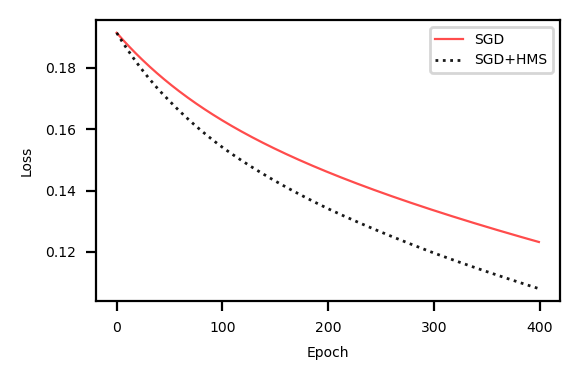

In [21]:
x1 = range(0, df1.shape[0])
x2 = range(0, df2.shape[0])
y1 = df1['loss'] 
y2 = df2['loss']  
plt.figure(figsize = (3,2), dpi = 200)
plt.plot(x1, y1, "r-", label = opti_name, linewidth = 0.8, alpha = 0.7)
plt.plot(x2, y2, "k:", label = opti_name+'+HMS', linewidth = 1, alpha = 0.9) 
plt.ylabel('Loss' , fontdict = {'fontsize':5})
plt.xlabel('Epoch', fontdict = {'fontsize':5}) 
#plt.yscale('log')
#plt.title("Loss", fontdict = {'fontname':'Times New Roman', 'fontsize':8})
plt.xticks(fontsize = 5)
plt.yticks(fontsize = 5)
plt.tight_layout()
plt.legend(prop={'size': 5})
#plt.savefig("graph.png",bbox_inches='tight',dpi=(300)) 
plt.show()

#### Training cost

In [22]:
print(f'Taining cost on {opti_name} = {round(df1.iloc[num_epochs-1].loss, 3)}')
print(f'Taining cost on {opti_name}+HMS = {round(df2.iloc[num_epochs-1].loss, 3)}')

Taining cost on SGD = 0.123
Taining cost on SGD+HMS = 0.108


#### Testing the model

Generic opimizer model

In [23]:
generic_testing_cost = model_wihtout_hms.evaluate(X_test, y_test)
generic_testing_cost  

9/9 [==============================] - 0s 682us/step - loss: 0.1442


0.14419984817504883

HMS-based optimizer model

In [24]:
hms_testing_cost = model_with_hms.evaluate(X_test, y_test)
hms_testing_cost

9/9 [==============================] - 0s 725us/step - loss: 0.1273


0.12727469205856323

<h2 style="color:blue" align="center">Training Loss vs Validation Loss</h2>

For generic optimizer

In [25]:
model_wihtout_hms_val = get_model()
model_wihtout_hms_val.set_weights(weights) 
history = model_wihtout_hms_val.fit(X_train, y_train, epochs = num_epochs, verbose=0, validation_split=0.2, batch_size=batch_size) 

In [26]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

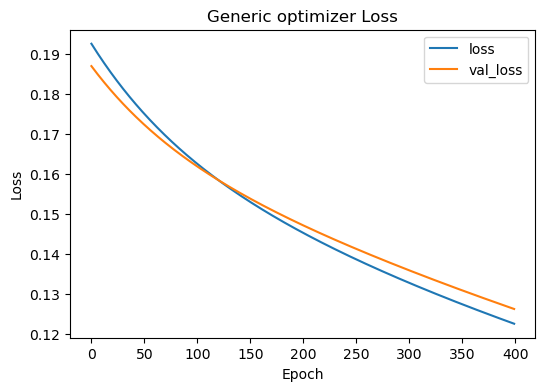

In [27]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Generic optimizer Loss')
#plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

For HMS-based optimizer

In [28]:
model_with_hms_val = get_model()
model_with_hms_val.set_weights(weights) 
history_hms = model_with_hms_val.fit(X_train, y_train, epochs = num_epochs, verbose=0, validation_split=0.2, callbacks=[CustomCallbackHMS(model_with_hms_val)], batch_size=batch_size) 

In [29]:
history_hms.history.keys()

dict_keys(['loss', 'val_loss'])

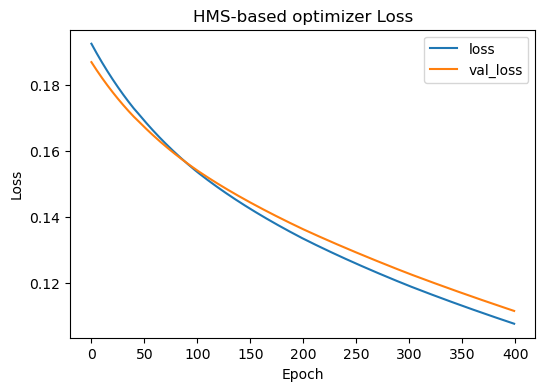

In [30]:
plt.figure(figsize=(6,4))
plt.plot(history_hms.history['loss'])
plt.plot(history_hms.history['val_loss'])
plt.title('HMS-based optimizer Loss')
#plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

<h2 style="color:blue" align="center">Validation with 10 Random Executions</h2>

In [31]:
num_exe = 10 
loss = [] 
loss_hms = []  

for i in tqdm(np.arange(num_exe)):          
        # Load data
        X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
        temp_model = get_model()
        temp_weights = temp_model.get_weights() 

        # Model without HMS    
        val_model = get_model()
        val_model.set_weights(temp_weights)    
        val_model.fit(X_train, y_train, epochs = num_epochs, verbose = 0, batch_size = batch_size) 
        scores = val_model.evaluate(X_test, y_test, verbose = 0)
        loss.append(round(scores, 4)) 

        # Model with HMS
        val_model_hms = get_model()
        val_model_hms.set_weights(temp_weights)     
        val_model_hms.fit(X_train, y_train, epochs = num_epochs, verbose = 0, callbacks=[CustomCallbackHMS(val_model_hms)], batch_size = batch_size) 
        scores_hms = val_model_hms.evaluate(X_test, y_test, verbose = 0)
        loss_hms.append(round(scores_hms, 4)) 
        #print('Execution ',i, 'is completed')  

results = pd.DataFrame(list(zip(loss, loss_hms)), columns = [opti_name, opti_name+'+HMS'])
results.to_csv('Results/Insurance/'+opti_name+' summary.csv')

100%|██████████| 10/10 [00:11<00:00,  1.11s/it]


In [32]:
print('----------------------------------------------') 
print(f'                {opti_name} vs {opti_name}+HMS     ')
print('----------------------------------------------')
print(f'Training set size     : {X_train.shape[0]} samples        ')
print(f'Batch size            : {batch_size} samples      ')
print('----------------------------------------------')
print(f'Training time for single run with {num_epochs} epochs')
print('----------------------------------------------')
print(f'{opti_name}           : {round(elapsed_training_time_generic,4)} seconds') 
print(f'{opti_name}+HMS       : {round(elapsed_training_time_hms,4)} seconds')
print('----------------------------------------------')
print(f'Training cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(df1.iloc[num_epochs-1].loss, 4)}') 
print(f'{opti_name}+HMS       : {round(df2.iloc[num_epochs-1].loss, 4)}')
print('----------------------------------------------')
print(f'Testing cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(generic_testing_cost, 4)}') 
print(f'{opti_name}+HMS       : {round(hms_testing_cost, 4)}')
print('----------------------------------------------')   
print('''Test set loss on different runs with different 
          weights initilization''')
print('----------------------------------------------')
print(results)
print('----------------------------------------------')
print('            Average loss with test set        ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].mean(),4)} (+- {round(results[results.columns[0]].std(),4)})')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].mean(),4)} (+- {round(results[results.columns[1]].std(),4)})')
print('----------------------------------------------') 
print('       Model that produces minimum loss       ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].min(),4)}')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].min(),4)}')
print('----------------------------------------------') 

----------------------------------------------
                SGD vs SGD+HMS     
----------------------------------------------
Training set size     : 1070 samples        
Batch size            : 1070 samples      
----------------------------------------------
Training time for single run with 400 epochs
----------------------------------------------
SGD           : 0.7639 seconds
SGD+HMS       : 0.5942 seconds
----------------------------------------------
Training cost for single run                 
----------------------------------------------
SGD           : 0.1232
SGD+HMS       : 0.108
----------------------------------------------
Testing cost for single run                 
----------------------------------------------
SGD           : 0.1442
SGD+HMS       : 0.1273
----------------------------------------------
Test set loss on different runs with different 
          weights initilization
----------------------------------------------
      SGD  SGD+HMS
0  0.1217   0.1035

#### Release the GPU memory

In [33]:
from numba import cuda 
device = cuda.get_current_device()
device.reset()